# ML Classification Basics — Financial Trade Prediction

**Goal:** Predict whether a stock trade will be **profitable** (binary classification) using financial features.

This notebook covers the full ML pipeline: data loading, preprocessing, feature engineering, normalization, model training, evaluation, and inference.

---

## Section 1: Introduction to Machine Learning

### What is Machine Learning?

Machine Learning is the practice of teaching computers to learn patterns from data, rather than explicitly programming rules.

### Three Main Types of ML

| Type | What it does | Example |
|---|---|---|
| **Supervised** | Learns from labeled data (input → known output) | Predict if trade is profitable (this notebook) |
| **Unsupervised** | Finds hidden patterns in unlabeled data | Cluster stocks by trading behavior |
| **Reinforcement** | Learns by trial-and-error with rewards/penalties | Algorithmic trading bots |

### Classification vs Regression

| | Classification | Regression |
|---|---|---|
| **Output** | Discrete category (Yes/No, A/B/C) | Continuous number (price, temperature) |
| **Example** | Will this trade be profitable? | What will the stock price be tomorrow? |
| **Metrics** | Accuracy, Precision, Recall, F1 | MAE, MSE, R² |
| **Algorithms** | Logistic Regression, Decision Tree, SVM | Linear Regression, Random Forest Regressor |

> **Interview Tip:** "Classification predicts *which category*, regression predicts *how much*." 

### The ML Pipeline (High-Level)

```
Raw Data → Clean/Preprocess → Feature Engineering → Split (Train/Test)
    → Train Model → Evaluate → Tune → Deploy/Inference
```

---

## Section 2: Loading & Exploring the Dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')

df = pd.read_csv('data/stock_trades.csv')
print(f"Shape: {df.shape}")
df.head()

Shape: (1000, 13)


,trade_id,symbol,sector,buy_price,sell_price,volume,holding_days,market_cap_billion,pe_ratio,daily_volatility,moving_avg_50,rsi,profitable
0,1,AMZN,E-Commerce,158.70,173.23,41343,56,1605.5,40.82,1.901,165.10,67.14,1
1,2,TSLA,Automotive,261.76,232.09,37264,76,836.3,32.87,2.308,250.00,20.58,0
2,3,MSFT,Technology,416.72,409.61,42151,31,2724.1,29.85,2.762,431.87,18.40,0
3,4,TSLA,Automotive,241.03,292.94,13418,88,811.2,32.77,4.278,237.20,46.36,1
4,5,TSLA,Automotive,270.67,275.59,17300,119,760.5,30.75,3.429,281.48,46.19,1


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   trade_id            1000 non-null   int64  
 1   symbol              1000 non-null   object 
 2   sector              1000 non-null   object 
 3   buy_price           1000 non-null   float64
 4   sell_price          1000 non-null   float64
 5   volume              1000 non-null   int64  
 6   holding_days        1000 non-null   int64  
 7   market_cap_billion  1000 non-null   float64
 8   pe_ratio            1000 non-null   float64
 9   daily_volatility    1000 non-null   float64
 10  moving_avg_50       1000 non-null   float64
 11  rsi                 1000 non-null   float64
 12  profitable          1000 non-null   int64  
dtypes: float64(7), int64(4), object(2)
memory usage: 101.7+ KB


In [3]:
df.describe()

,trade_id,buy_price,sell_price,volume,holding_days,market_cap_billion,pe_ratio,daily_volatility,moving_avg_50,rsi,profitable
count,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,500.500000,223.560900,228.392790,25236.52500,60.844000,1958.274100,34.382760,2.670112,223.653510,50.693240,0.612000
std,288.819436,85.847939,89.814818,14362.00113,34.518621,745.613595,14.222316,1.331134,85.814206,20.374886,0.487538
min,1.000000,119.520000,105.630000,182.00000,1.000000,656.400000,10.050000,0.503000,114.620000,15.130000,0.000000
25%,250.750000,159.360000,163.147500,12713.75000,30.000000,1564.950000,22.167500,1.487250,159.725000,33.260000,0.000000
50%,500.500000,189.070000,196.305000,25618.50000,61.000000,1903.400000,33.915000,2.646500,189.325000,51.350000,1.000000
75%,750.250000,263.222500,268.470000,36872.50000,90.000000,2732.425000,46.665000,3.786250,263.700000,68.435000,1.000000
max,1000.000000,436.750000,508.140000,49950.00000,119.000000,2928.700000,59.880000,4.999000,447.830000,84.980000,1.000000


### Check Class Balance

> **Interview Tip:** Always check if the target variable is balanced. If one class dominates (e.g., 95% vs 5%), accuracy becomes misleading — a model that always predicts the majority class gets 95% accuracy but is useless.

Target distribution:
profitable
1    612
0    388
Name: count, dtype: int64

Percentage profitable: 61.2%


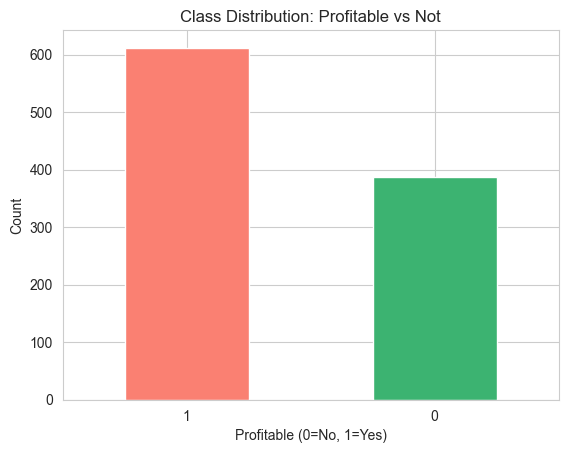

In [4]:
print("Target distribution:")
print(df['profitable'].value_counts())
print(f"\nPercentage profitable: {df['profitable'].mean() * 100:.1f}%")

df['profitable'].value_counts().plot(kind='bar', color=['salmon', 'mediumseagreen'])
plt.title('Class Distribution: Profitable vs Not')
plt.xlabel('Profitable (0=No, 1=Yes)')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

In [5]:
print("Missing values per column:")
print(df.isnull().sum())

Missing values per column:
trade_id              0
symbol                0
sector                0
buy_price             0
sell_price            0
volume                0
holding_days          0
market_cap_billion    0
pe_ratio              0
daily_volatility      0
moving_avg_50         0
rsi                   0
profitable            0
dtype: int64


---

## Section 3: Data Preprocessing

### Handling Categorical Variables

ML models work with numbers, not strings. We need to convert categorical columns (`symbol`, `sector`) to numeric form.

**Two common approaches:**

| Method | How it works | When to use |
|---|---|---|
| **Label Encoding** | Maps each category to a number (A=0, B=1, C=2) | Ordinal data (Low < Medium < High), tree-based models |
| **One-Hot Encoding** | Creates a binary column per category | Nominal data (no order), linear models |

> **Interview Tip:** Label encoding introduces a *false ordering* (AAPL=0 < GOOG=1 < MSFT=2). This is fine for tree-based models (they split on thresholds), but misleading for linear models. One-hot encoding avoids this but increases dimensionality.

In [6]:
from sklearn.preprocessing import LabelEncoder

# --- Label Encoding (for demonstration) ---
le_symbol = LabelEncoder()
le_sector = LabelEncoder()

df['symbol_encoded'] = le_symbol.fit_transform(df['symbol'])
df['sector_encoded'] = le_sector.fit_transform(df['sector'])

print("Label Encoding mapping:")
print(f"  Symbols: {dict(zip(le_symbol.classes_, le_symbol.transform(le_symbol.classes_)))}")
print(f"  Sectors: {dict(zip(le_sector.classes_, le_sector.transform(le_sector.classes_)))}")

Label Encoding mapping:
  Symbols: {'AAPL': np.int64(0), 'AMZN': np.int64(1), 'GOOG': np.int64(2), 'MSFT': np.int64(3), 'TSLA': np.int64(4)}
  Sectors: {'Automotive': np.int64(0), 'E-Commerce': np.int64(1), 'Technology': np.int64(2)}


In [8]:
# --- One-Hot Encoding (preferred for linear models) ---
df_onehot = pd.get_dummies(df, columns=['symbol', 'sector'], drop_first=True)
print("Columns after one-hot encoding:")
print(df_onehot.columns.tolist())

df.head(5)

Columns after one-hot encoding:
['trade_id', 'buy_price', 'sell_price', 'volume', 'holding_days', 'market_cap_billion', 'pe_ratio', 'daily_volatility', 'moving_avg_50', 'rsi', 'profitable', 'symbol_encoded', 'sector_encoded', 'symbol_AMZN', 'symbol_GOOG', 'symbol_MSFT', 'symbol_TSLA', 'sector_E-Commerce', 'sector_Technology']


,trade_id,symbol,sector,buy_price,sell_price,volume,holding_days,market_cap_billion,pe_ratio,daily_volatility,moving_avg_50,rsi,profitable,symbol_encoded,sector_encoded
0,1,AMZN,E-Commerce,158.70,173.23,41343,56,1605.5,40.82,1.901,165.10,67.14,1,1,1
1,2,TSLA,Automotive,261.76,232.09,37264,76,836.3,32.87,2.308,250.00,20.58,0,4,0
2,3,MSFT,Technology,416.72,409.61,42151,31,2724.1,29.85,2.762,431.87,18.40,0,3,2
3,4,TSLA,Automotive,241.03,292.94,13418,88,811.2,32.77,4.278,237.20,46.36,1,4,0
4,5,TSLA,Automotive,270.67,275.59,17300,119,760.5,30.75,3.429,281.48,46.19,1,4,0


We will use **one-hot encoded** data going forward since we'll be using Logistic Regression (a linear model).

---

## Section 4: Feature Engineering

Feature engineering is the process of creating new features from existing data to help the model learn better patterns.

> **Interview Tip:** Feature engineering is often the single biggest factor in model performance. A simple model with great features beats a complex model with poor features.

**Common techniques:**
- Ratios and percentages (e.g., price change %)
- Interaction features (e.g., volume × price)
- Binning continuous variables into categories
- Domain-specific transformations

In [9]:
# 1. Price change percentage
df_onehot['price_change_pct'] = ((df['sell_price'] - df['buy_price']) / df['buy_price']) * 100

# 2. Volume-price interaction (higher volume at higher prices = larger position)
df_onehot['volume_price'] = df['volume'] * df['buy_price']

# 3. RSI category — a classic trading indicator interpretation
#    RSI > 70 = overbought (might fall), RSI < 30 = oversold (might rise)
def rsi_category(rsi):
    if rsi >= 70:
        return 2  # overbought
    elif rsi <= 30:
        return 0  # oversold
    return 1      # neutral

df_onehot['rsi_cat'] = df['rsi'].apply(rsi_category)

# 4. Price relative to 50-day moving average
#    buy_price > MA50 means stock is trending up
df_onehot['price_above_ma50'] = (df['buy_price'] > df['moving_avg_50']).astype(int)

print("New features added:")
print(df_onehot[['price_change_pct', 'volume_price', 'rsi_cat', 'price_above_ma50']].describe())

New features added:
       price_change_pct  volume_price      rsi_cat  price_above_ma50
count       1000.000000  1.000000e+03  1000.000000       1000.000000
mean           2.118913  5.624612e+06     1.018000          0.481000
std            8.011812  4.018204e+06     0.660388          0.499889
min          -27.574248  2.903082e+04     0.000000          0.000000
25%           -3.395037  2.521353e+06     1.000000          0.000000
50%            2.285960  4.969983e+06     1.000000          0.000000
75%            7.349892  7.637194e+06     1.000000          1.000000
max           29.314162  2.091508e+07     2.000000          1.000000


### Prepare Feature Matrix (X) and Target (y)

Drop columns that should **not** be used as features:
- `trade_id` — just an identifier
- `sell_price` — leaks the answer (if we know sell price, we already know if it's profitable)
- `price_change_pct` — also derived from sell_price, so it leaks
- `profitable` — this is our target

> **Interview Tip:** **Data leakage** happens when your training data contains information that would not be available at prediction time. It gives artificially high scores during training but fails in production.

In [10]:
drop_cols = ['trade_id', 'sell_price', 'price_change_pct', 'profitable',
             'symbol_encoded', 'sector_encoded']

X = df_onehot.drop(columns=drop_cols)
y = df_onehot['profitable']

print(f"Features shape: {X.shape}")
print(f"Target shape:   {y.shape}")
print(f"\nFeature columns ({len(X.columns)}):")
print(X.columns.tolist())

Features shape: (1000, 17)
Target shape:   (1000,)

Feature columns (17):
['buy_price', 'volume', 'holding_days', 'market_cap_billion', 'pe_ratio', 'daily_volatility', 'moving_avg_50', 'rsi', 'symbol_AMZN', 'symbol_GOOG', 'symbol_MSFT', 'symbol_TSLA', 'sector_E-Commerce', 'sector_Technology', 'volume_price', 'rsi_cat', 'price_above_ma50']


---

## Section 5: Normalization & Scaling

Features have different scales (e.g., `volume` is in thousands, `daily_volatility` is 0-5). Many ML algorithms (Logistic Regression, SVM, KNN) are sensitive to feature scale. Tree-based models (Decision Tree, Random Forest) are **not** affected.

### Three Common Scalers

| Scaler | Formula | Range | When to use |
|---|---|---|---|
| **StandardScaler** | (x - mean) / std | Centered at 0, ~[-3, 3] | Default choice. Assumes roughly normal distribution. |
| **MinMaxScaler** | (x - min) / (max - min) | [0, 1] | When you need bounded values (e.g., neural networks). |
| **RobustScaler** | (x - median) / IQR | Centered at 0 | When data has outliers (median/IQR are robust to outliers). |

> **Interview Tip:** "I use StandardScaler as default. If there are significant outliers, I switch to RobustScaler. MinMaxScaler is best when the algorithm requires bounded input (like neural networks with sigmoid activation)."

> **Critical Rule:** Always `fit` the scaler on **training data only**, then `transform` both train and test. Fitting on the full dataset causes data leakage.

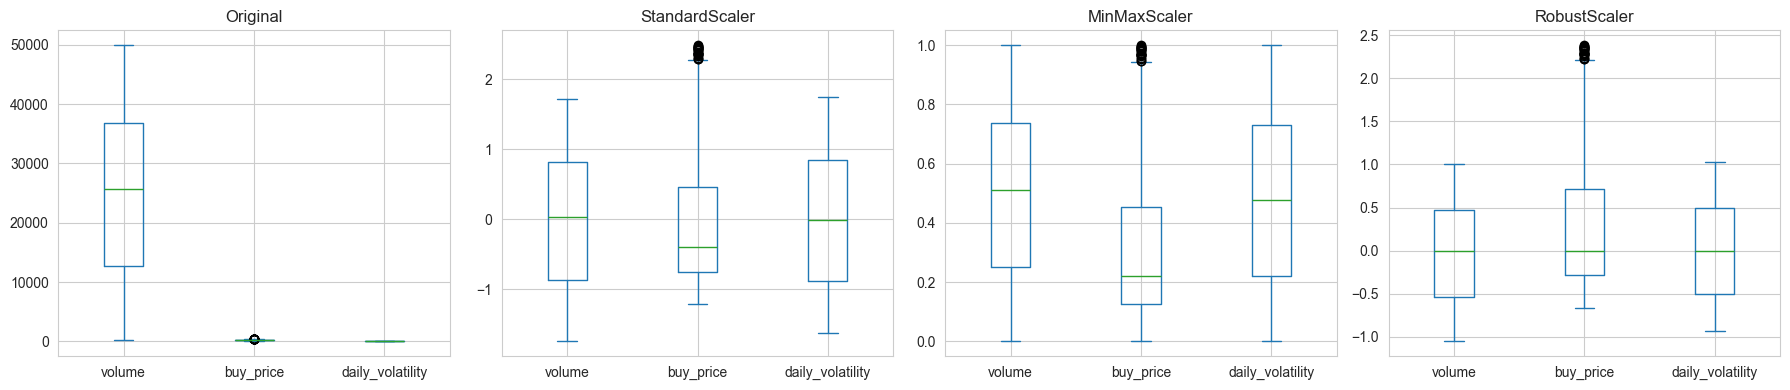

In [11]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler

# Let's compare all three on a sample column: 'volume'
sample = df[['volume', 'buy_price', 'daily_volatility']].copy()

fig, axes = plt.subplots(1, 4, figsize=(18, 4))

axes[0].set_title('Original')
sample.plot(kind='box', ax=axes[0])

for i, (name, scaler) in enumerate([
    ('StandardScaler', StandardScaler()),
    ('MinMaxScaler', MinMaxScaler()),
    ('RobustScaler', RobustScaler())
]):
    scaled = pd.DataFrame(scaler.fit_transform(sample), columns=sample.columns)
    axes[i + 1].set_title(name)
    scaled.plot(kind='box', ax=axes[i + 1])

plt.tight_layout()
plt.show()

We'll use **StandardScaler** for this notebook (good default for Logistic Regression).

---

## Section 6: Train-Test Split

We split the data so the model trains on one portion and is evaluated on unseen data.

| Split | Typical ratio | Purpose |
|---|---|---|
| **Train** | 70-80% | Model learns from this |
| **Test** | 20-30% | Final evaluation on unseen data |
| **Validation** (optional) | 10-15% from train | Hyperparameter tuning |

> **Interview Tip:** Use `stratify=y` to ensure both train and test sets have the same class distribution as the original data. Without stratification, a random split might put 90% of one class in train and 10% in test.

In [12]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train set: {X_train.shape[0]} samples")
print(f"Test set:  {X_test.shape[0]} samples")
print(f"\nTrain class distribution: {y_train.value_counts().to_dict()}")
print(f"Test class distribution:  {y_test.value_counts().to_dict()}")

Train set: 800 samples
Test set:  200 samples

Train class distribution: {1: 490, 0: 310}
Test class distribution:  {1: 122, 0: 78}


In [14]:
# Scale AFTER splitting — fit on train, transform both
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns, index=X_test.index)

print("Scaled train set sample (first 3 rows):")
X_train_scaled.head(3)

Scaled train set sample (first 3 rows):


,buy_price,volume,holding_days,market_cap_billion,pe_ratio,daily_volatility,moving_avg_50,rsi,symbol_AMZN,symbol_GOOG,symbol_MSFT,symbol_TSLA,sector_E-Commerce,sector_Technology,volume_price,rsi_cat,price_above_ma50
647,0.681162,-0.155398,-0.952258,-1.612588,-1.440304,1.520908,0.535681,0.778691,-0.501952,-0.464549,-0.492175,1.961756,-0.501952,-1.205814,0.205657,-0.024971,1.022759
763,0.158584,1.043991,0.289739,-1.430267,1.151191,-1.291641,0.190985,0.931668,-0.501952,-0.464549,-0.492175,1.961756,-0.501952,-1.205814,0.973971,-0.024971,-0.977748
585,0.190445,0.513752,0.780761,-1.580054,0.054547,1.346533,0.290502,-1.349113,-0.501952,-0.464549,-0.492175,1.961756,-0.501952,-1.205814,0.544864,-1.561640,-0.977748


---

## Section 7: Model Training — Classification Models

We will train three fundamental classifiers and compare their performance.

### 7.1 Logistic Regression

Despite the name, Logistic Regression is a **classification** algorithm. It models the probability that an input belongs to a class using the **sigmoid function**.

```
P(y=1|x) = 1 / (1 + e^(-z))    where z = w·x + b
```

- Output is a probability between 0 and 1
- Decision boundary: if P >= 0.5 → class 1, else class 0
- Works well when relationship between features and target is roughly linear

> **Interview Tip:** "Logistic Regression is my go-to baseline for binary classification. It's fast, interpretable, and gives probabilities. If it performs well, I don't need a more complex model."

In [15]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(random_state=42, max_iter=1000)
lr_model.fit(X_train_scaled, y_train)

lr_train_acc = lr_model.score(X_train_scaled, y_train)
lr_test_acc = lr_model.score(X_test_scaled, y_test)

print(f"Logistic Regression:")
print(f"  Train accuracy: {lr_train_acc:.4f}")
print(f"  Test accuracy:  {lr_test_acc:.4f}")

Logistic Regression:
  Train accuracy: 0.6112
  Test accuracy:  0.5950


### 7.2 Decision Tree

A Decision Tree splits data by asking yes/no questions on features, creating a tree structure. At each node, it picks the split that best separates the classes.

**Split criteria:**
- **Gini Impurity:** Measures how "mixed" a node is. Gini = 0 means perfectly pure (all one class). Formula: `1 - Σ(pᵢ²)`
- **Entropy (Information Gain):** Measures disorder. Entropy = 0 means pure. Formula: `-Σ(pᵢ · log₂(pᵢ))`

**Pros:** Easy to interpret, no scaling needed, handles non-linear relationships.  
**Cons:** Prone to overfitting (memorizes training data).

> **Interview Tip:** "A single Decision Tree tends to overfit. That's why we use ensembles like Random Forest — they combine many trees to reduce variance."

In [18]:
from sklearn.tree import DecisionTreeClassifier

# max_depth limits tree depth to prevent overfitting
dt_model = DecisionTreeClassifier(random_state=42, max_depth=5)
dt_model.fit(X_train_scaled, y_train)

dt_train_acc = dt_model.score(X_train_scaled, y_train)
dt_test_acc = dt_model.score(X_test_scaled, y_test)

print(f"Decision Tree:")
print(f"  Train accuracy: {dt_train_acc:.4f}")
print(f"  Test accuracy:  {dt_test_acc:.4f}")

Decision Tree:
  Train accuracy: 0.6650
  Test accuracy:  0.5650


### 7.3 Random Forest

Random Forest is an **ensemble** method that trains multiple Decision Trees on random subsets of the data and features, then takes a majority vote.

**How it works:**
1. Create N random subsets of training data (with replacement — **bagging**)
2. Train a Decision Tree on each subset, using a random subset of features at each split
3. For prediction, each tree votes and the majority wins

**Why it works better than a single tree:**
- Each tree overfits in a different way
- Averaging/voting cancels out individual errors
- This is the **bias-variance tradeoff** in action: individual trees have low bias but high variance; the ensemble reduces variance

> **Interview Tip:** "Random Forest reduces overfitting by averaging many decorrelated trees. The randomness in feature selection at each split ensures the trees are diverse."

In [16]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=5)
rf_model.fit(X_train_scaled, y_train)

rf_train_acc = rf_model.score(X_train_scaled, y_train)
rf_test_acc = rf_model.score(X_test_scaled, y_test)

print(f"Random Forest:")
print(f"  Train accuracy: {rf_train_acc:.4f}")
print(f"  Test accuracy:  {rf_test_acc:.4f}")

Random Forest:
  Train accuracy: 0.7000
  Test accuracy:  0.6200


              Model  Train Accuracy  Test Accuracy
Logistic Regression         0.61125          0.595
      Decision Tree         0.66500          0.565
      Random Forest         0.70000          0.620


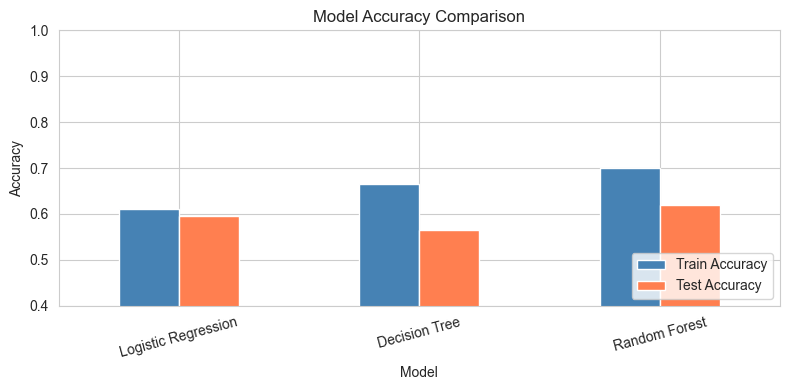

In [19]:
# --- Compare all three models ---
results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Decision Tree', 'Random Forest'],
    'Train Accuracy': [lr_train_acc, dt_train_acc, rf_train_acc],
    'Test Accuracy': [lr_test_acc, dt_test_acc, rf_test_acc]
})

print(results.to_string(index=False))

results.set_index('Model')[['Train Accuracy', 'Test Accuracy']].plot(
    kind='bar', figsize=(8, 4), color=['steelblue', 'coral']
)
plt.title('Model Accuracy Comparison')
plt.ylabel('Accuracy')
plt.ylim(0.4, 1.0)
plt.xticks(rotation=15)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

---

## Section 8: Model Evaluation

Accuracy alone is not enough. We need to understand **where** the model makes mistakes.

### Key Metrics

| Metric | Formula | What it answers |
|---|---|---|
| **Accuracy** | (TP + TN) / Total | Overall, how often is the model correct? |
| **Precision** | TP / (TP + FP) | Of all predicted positives, how many are actually positive? |
| **Recall** | TP / (TP + FN) | Of all actual positives, how many did we catch? |
| **F1-Score** | 2 × (P × R) / (P + R) | Harmonic mean of Precision and Recall |

Where: TP = True Positive, TN = True Negative, FP = False Positive, FN = False Negative

> **Interview Tip — Precision vs Recall tradeoff:**
> - **High Precision matters** when false positives are costly (e.g., spam filter — don't want real emails in spam)
> - **High Recall matters** when false negatives are costly (e.g., cancer detection — don't want to miss a sick patient)
> - F1-Score balances both, useful when classes are imbalanced

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# Pick the best model for detailed evaluation
best_model = rf_model
best_name = 'Random Forest'
y_pred = best_model.predict(X_test_scaled)

print(f"=== {best_name} — Classification Report ===")
print(classification_report(y_test, y_pred, target_names=['Not Profitable', 'Profitable']))

In [ ]:
# --- Confusion Matrix ---
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=['Not Profitable', 'Profitable'])
disp.plot(ax=ax, cmap='Blues', values_format='d')
plt.title(f'{best_name} — Confusion Matrix')
plt.show()

### Reading the Confusion Matrix

```
                  Predicted
                  Not Prof.   Profitable
Actual Not Prof.  [ TN          FP ]
Actual Profitable [ FN          TP ]
```

- **TN (top-left):** Correctly predicted not profitable
- **TP (bottom-right):** Correctly predicted profitable
- **FP (top-right):** Predicted profitable but actually wasn't (false alarm)
- **FN (bottom-left):** Predicted not profitable but actually was (missed opportunity)

In [ ]:
# --- Feature Importance (Random Forest) ---
importances = pd.Series(rf_model.feature_importances_, index=X.columns)
importances = importances.sort_values(ascending=True)

plt.figure(figsize=(8, 6))
importances.tail(10).plot(kind='barh', color='teal')
plt.title('Top 10 Feature Importances (Random Forest)')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

> **Interview Tip:** Feature importance from tree-based models shows which features the model relies on most. High importance doesn't mean causation — it means the feature was useful for splitting the data.

---

## Section 9: Model Inference

Inference means using a trained model to make predictions on new, unseen data.

### `predict()` vs `predict_proba()`

| Method | Returns | Use case |
|---|---|---|
| `predict(X)` | Class label (0 or 1) | When you need a hard decision |
| `predict_proba(X)` | Probability for each class | When you need confidence scores, or want a custom threshold |

In [ ]:
# Simulate 3 new trades that the model has never seen
new_trades = pd.DataFrame({
    'buy_price':           [150.0,  350.0,  220.0],
    'volume':              [5000,   15000,  800],
    'holding_days':        [10,     45,     90],
    'market_cap_billion':  [2800,   2700,   800],
    'pe_ratio':            [28.5,   35.0,   55.0],
    'daily_volatility':    [1.2,    0.8,    4.5],
    'moving_avg_50':       [148.0,  360.0,  210.0],
    'rsi':                 [55.0,   75.0,   22.0],
    'volume_price':        [5000*150, 15000*350, 800*220],
    'rsi_cat':             [1,      2,      0],
    'price_above_ma50':    [1,      0,      1],
})

# Add one-hot columns matching training data (fill missing with 0)
for col in X.columns:
    if col not in new_trades.columns:
        new_trades[col] = 0

# Set the appropriate one-hot flags
# Trade 1: AAPL/Technology, Trade 2: MSFT/Technology, Trade 3: TSLA/Automotive
new_trades.loc[1, 'symbol_MSFT'] = 1
new_trades.loc[2, 'symbol_TSLA'] = 1

new_trades = new_trades[X.columns]  # ensure same column order

# Scale using the SAME scaler fitted on training data
new_trades_scaled = pd.DataFrame(
    scaler.transform(new_trades), columns=X.columns
)

print("New trades (raw):")
print(new_trades[['buy_price', 'volume', 'holding_days', 'rsi']].to_string())

In [ ]:
# --- predict() — hard class labels ---
predictions = rf_model.predict(new_trades_scaled)
print("Predicted classes:", predictions)
print("  ", ['Not Profitable' if p == 0 else 'Profitable' for p in predictions])

# --- predict_proba() — confidence scores ---
probabilities = rf_model.predict_proba(new_trades_scaled)
print("\nPredicted probabilities:")
for i, (prob, pred) in enumerate(zip(probabilities, predictions)):
    label = 'Profitable' if pred == 1 else 'Not Profitable'
    print(f"  Trade {i+1}: P(Not Profitable)={prob[0]:.3f}, P(Profitable)={prob[1]:.3f} → {label}")

### Saving and Loading a Model

In production, you train once and save the model. Later, you load it for inference without retraining.

**Common serialization options:**
- `joblib` — optimized for NumPy arrays, preferred for sklearn models
- `pickle` — Python's built-in serializer, works but slower for large arrays

In [ ]:
import joblib

# Save the model and scaler (both are needed for inference)
joblib.dump(rf_model, 'data/rf_model.joblib')
joblib.dump(scaler, 'data/scaler.joblib')
print("Model and scaler saved to data/ folder.")

# Load them back
loaded_model = joblib.load('data/rf_model.joblib')
loaded_scaler = joblib.load('data/scaler.joblib')

# Verify loaded model produces same results
loaded_preds = loaded_model.predict(loaded_scaler.transform(new_trades))
print(f"Loaded model predictions: {loaded_preds}")
print(f"Match original: {np.array_equal(predictions, loaded_preds)}")

---

## Section 10: Summary & Interview Quick Reference

### Key Terms Cheat Sheet

| Term | Definition |
|---|---|
| **Feature** | An input variable used to make predictions (e.g., buy_price, volume) |
| **Target / Label** | The output variable we want to predict (e.g., profitable) |
| **Training set** | Data the model learns from |
| **Test set** | Unseen data used to evaluate model performance |
| **Overfitting** | Model memorizes training data, performs poorly on new data |
| **Underfitting** | Model is too simple to capture patterns |
| **Bias** | Error from oversimplified assumptions (high bias = underfitting) |
| **Variance** | Error from sensitivity to training data fluctuations (high variance = overfitting) |
| **Data Leakage** | Using information during training that wouldn't be available at prediction time |
| **Feature Engineering** | Creating new features from raw data to improve model performance |
| **Normalization** | Scaling features to a common range so no single feature dominates |
| **Ensemble** | Combining multiple models to get better predictions (e.g., Random Forest) |

### Common Interview Questions (One-Line Answers)

**Q: What is the bias-variance tradeoff?**  
A: Simple models have high bias (underfit), complex models have high variance (overfit). The goal is to find the sweet spot.

**Q: When would you use Logistic Regression over Random Forest?**  
A: When interpretability matters, the dataset is small, or the relationship is roughly linear.

**Q: How do you handle imbalanced classes?**  
A: Oversample the minority class (SMOTE), undersample majority, use class weights, or evaluate with F1/AUC instead of accuracy.

**Q: What is cross-validation?**  
A: Splitting data into K folds, training on K-1 and testing on the remaining fold, rotating through all folds to get a robust performance estimate.

**Q: Why do we scale features?**  
A: Algorithms like Logistic Regression and KNN use distance/gradient calculations that are dominated by large-scale features if not normalized.

**Q: What is the difference between bagging and boosting?**  
A: Bagging trains models in parallel on random subsets (reduces variance, e.g., Random Forest). Boosting trains models sequentially, each fixing the previous one's errors (reduces bias, e.g., XGBoost).

**Q: How do you detect overfitting?**  
A: Large gap between train and test accuracy. Train accuracy is high but test accuracy is significantly lower.